In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split



In [3]:
df = pd.read_csv("loan_prediction.csv")      
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### dataset info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### handle missing values

In [8]:
from sklearn.impute import SimpleImputer

categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])


In [9]:

df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### EDA

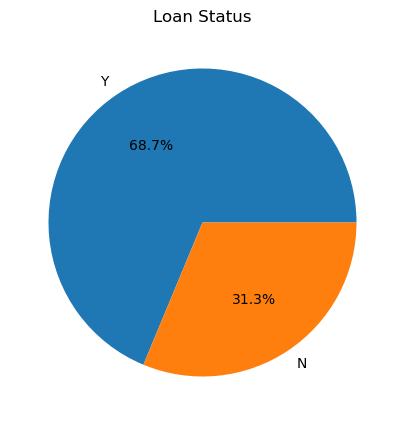

In [10]:
loan_count = df["Loan_Status"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(loan_count,
        labels=loan_count.index,
        autopct="%1.1f%%")
plt.title("Loan Status")
plt.show()

### Gender

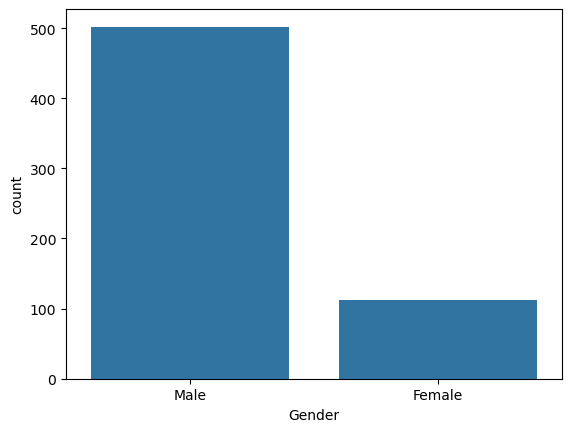

In [11]:
sns.countplot(x="Gender", data=df)
plt.show()


### Education

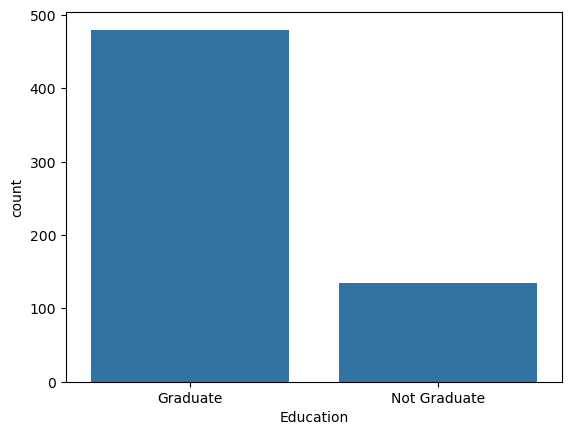

In [12]:
sns.countplot(x="Education", data=df)
plt.show()

### Applicant Income

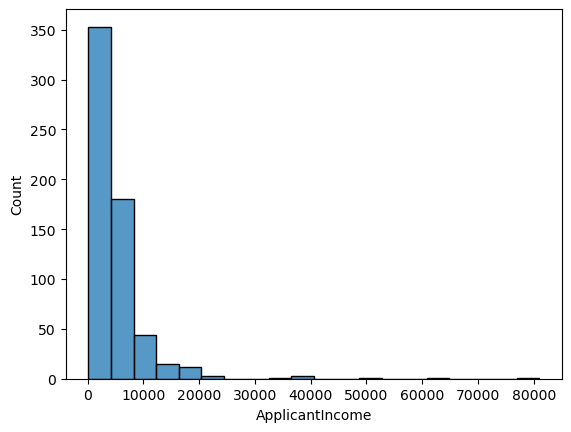

In [13]:
sns.histplot(df["ApplicantIncome"], bins=20)
plt.show()

### Loan Amount

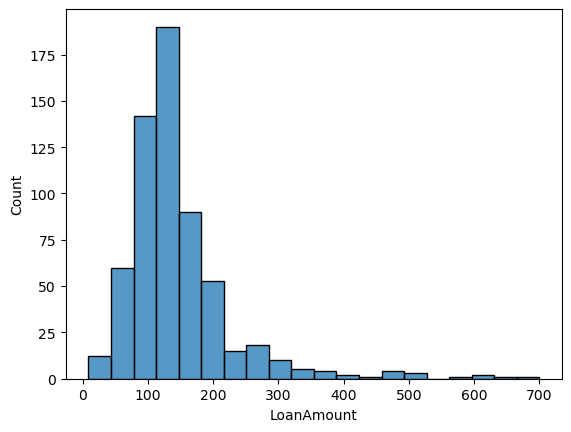

In [14]:
sns.histplot(df["LoanAmount"], bins=20)
plt.show()

### Boxplot

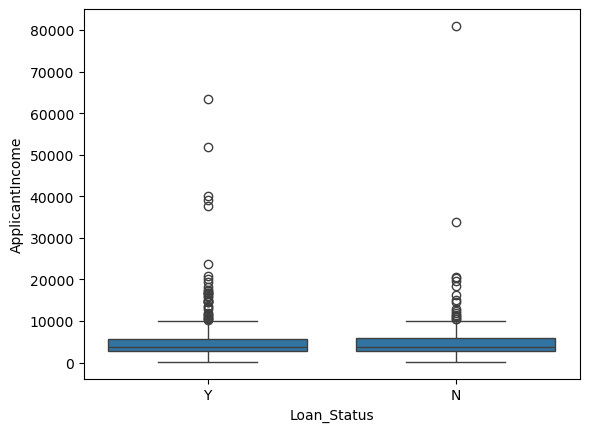

In [16]:
sns.boxplot(x="Loan_Status",
            y="ApplicantIncome",
            data=df)

plt.show()

### Encoding

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Binary Columns
binary_cols = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Loan_Status"
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One Hot Encoding
df = pd.get_dummies(df,
                    columns=["Property_Area"],
                    drop_first=True)

# Dependents contains 3+
df["Dependents"] = df["Dependents"].replace("3+",3)
df["Dependents"] = df["Dependents"].astype(float)


### Correlation Heatmap

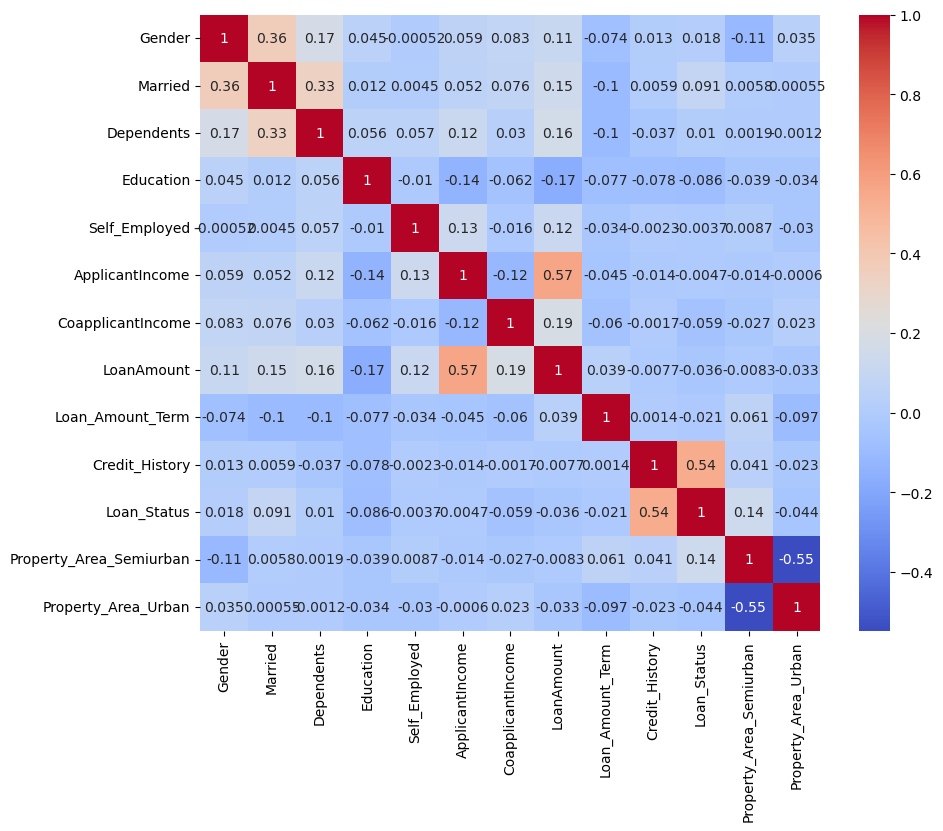

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

### Train-Test Split

In [22]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

log_model = LogisticRegression()

log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

Logistic Regression
Accuracy : 0.7886178861788617
Precision: 0.7596153846153846
Recall   : 0.9875
F1 Score : 0.8586956521739131
[[18 25]
 [ 1 79]]


### KNN

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled,y_train)

y_pred = knn.predict(X_test_scaled)

print("KNN")
print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

KNN
Accuracy : 0.7560975609756098
Precision: 0.75
Recall   : 0.9375
F1 Score : 0.8333333333333334
[[18 25]
 [ 5 75]]


### Naive Bayes